### Кластеризация

### Загрузка библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import joblib

### Загрузка датасета

In [2]:
df = pd.read_csv("patient_segmentation_dataset.csv")

### Задаем ключевые переменные

In [3]:
FEATURES = ['Age', 'BMI', 'Num_Chronic_Conditions', 'Annual_Visits', 'Avg_Billing_Amount']

In [4]:
X = df[FEATURES].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Метод локтя

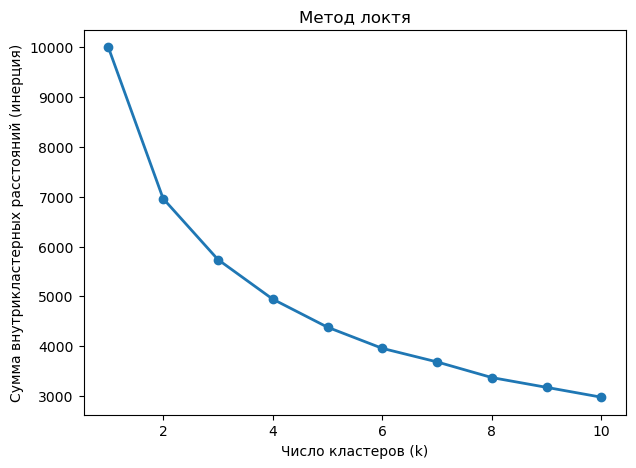

In [5]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia, marker='o', linewidth=2)
plt.title("Метод локтя")
plt.xlabel("Число кластеров (k)")
plt.ylabel("Сумма внутрикластерных расстояний (инерция)")
plt.show()

Прям явный сгиб не наблюдается, я думаю он есть в точке 6

### Проведем методы кластеризации

In [37]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.8, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

agg = AgglomerativeClustering(n_clusters=6, linkage='ward')
df['cluster_agg'] = agg.fit_predict(X_scaled)

Выведем метрики

In [38]:
def print_metrics(labels, name):
    if len(set(labels)) < 2:
        print(f"{name}: недостаточно кластеров")
        return
    sil = silhouette_score(X_scaled, labels)
    ch  = calinski_harabasz_score(X_scaled, labels)
    print(f"{name} - Sil: {sil:.3f}   CH: {ch:.1f}")

print_metrics(df['cluster_kmeans'], "KMeans")
print_metrics(df['cluster_dbscan'], "DBSCAN")
print_metrics(df['cluster_agg'], "Agglomerative")

KMeans - Sil: 0.245   CH: 609.4
DBSCAN - Sil: 0.165   CH: 261.4
Agglomerative - Sil: 0.208   CH: 521.7


In [39]:
print("\nKMeans кластеры:")
print(df.groupby('cluster_kmeans')[FEATURES].mean().round(2))
print("\nDBSCAN кластеры:")
print(df.groupby('cluster_dbscan')[FEATURES].mean().round(2))
print("\nAgglomerativeClustering кластеры:")
print(df.groupby('cluster_agg')[FEATURES].mean().round(2))


KMeans кластеры:
                  Age    BMI  Num_Chronic_Conditions  Annual_Visits  \
cluster_kmeans                                                        
0               51.89  42.45                    1.00           5.67   
1               54.47  25.56                    1.06           3.30   
2               69.44  31.22                    2.57           5.77   
3               30.59  29.38                    0.02           2.50   
4               68.73  30.38                    2.54           7.57   
5               52.88  27.19                    1.01           9.65   

                Avg_Billing_Amount  
cluster_kmeans                      
0                          4177.86  
1                          3971.67  
2                          8535.61  
3                          2549.34  
4                          2848.04  
5                          3988.03  

DBSCAN кластеры:
                  Age    BMI  Num_Chronic_Conditions  Annual_Visits  \
cluster_dbscan              

## Графически выведем методы

### KMeans

Наиболее простой, но в то же время достаточно неточный метод кластеризации в классической реализации. Он разбивает множество элементов векторного пространства на заранее известное число кластеров k.

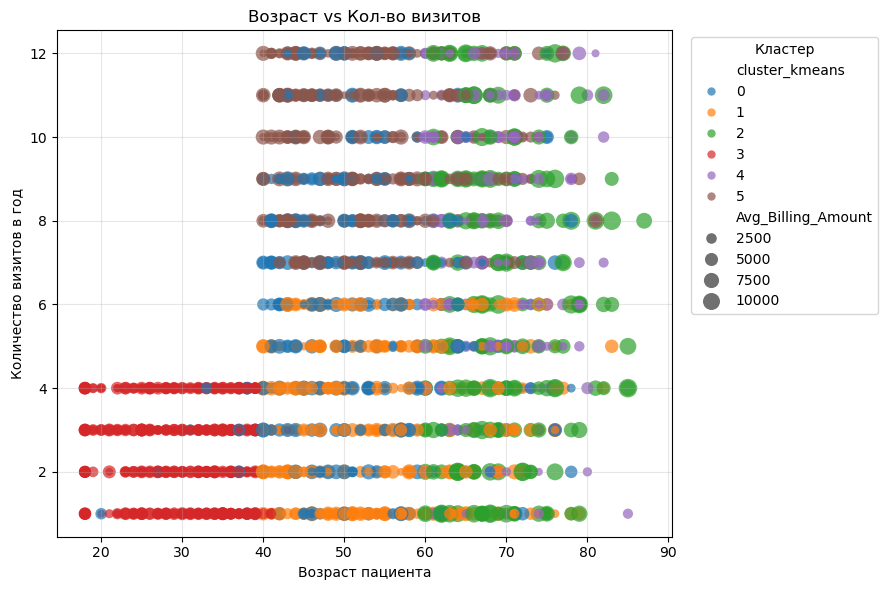

In [40]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual_Visits',
    hue='cluster_kmeans',
    palette='tab10',
    size='Avg_Billing_Amount',          # размер точки = кол-во визитов
    sizes=(30, 180),               # диапазон размеров
    alpha=0.7,
    edgecolor='none'
)

plt.title("Возраст vs Кол-во визитов")
plt.xlabel("Возраст пациента")
plt.ylabel("Количество визитов в год")
plt.legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### DBSCAN

DBSCAN ,как следует из названия, оперирует плотностью данных. На вход он просит уже знакомую матрицу близости и два загадочных параметра — радиус $\epsilon$-окрестности и количество соседей.

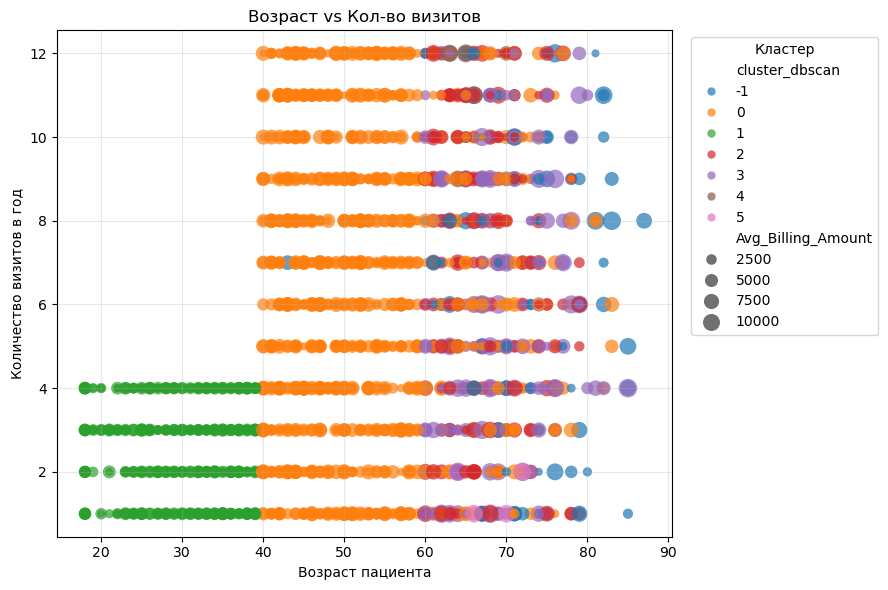

In [41]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual_Visits',
    hue='cluster_dbscan',
    palette='tab10',
    size='Avg_Billing_Amount',          # размер точки = кол-во визитов
    sizes=(30, 180),               # диапазон размеров
    alpha=0.7,
    edgecolor='none'
)

plt.title("Возраст vs Кол-во визитов")
plt.xlabel("Возраст пациента")
plt.ylabel("Количество визитов в год")
plt.legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### AgglomerativeClustering

Это метод иерархической кластеризации, который объединяет объекты в кластеры на основе их близости. Процесс кластеризации начинается с того, что изначально каждый объект считается отдельным кластером, а затем на каждом шаге два наиболее близких кластера сливаются в один, пока не будет достигнуто желаемое число кластеров или один общий кластер.

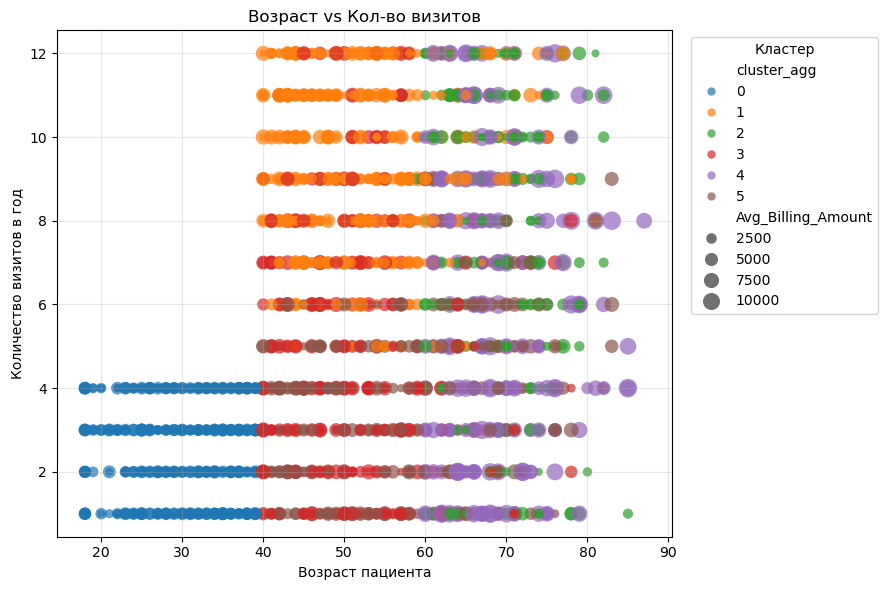

In [42]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual_Visits',
    hue='cluster_agg',
    palette='tab10',
    size='Avg_Billing_Amount',          # размер точки = кол-во визитов
    sizes=(30, 180),               # диапазон размеров
    alpha=0.7,
    edgecolor='none'
)

plt.title("Возраст vs Кол-во визитов")
plt.xlabel("Возраст пациента")
plt.ylabel("Количество визитов в год")
plt.legend(title="Кластер", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

У каждого кластера получились разные графики, но в плане качества довольно похожи. Как я считаю, лучший график получился у DBSCAN.

### Описание кластеров

Выведем данные кластеров по столбцам датасета.

In [43]:
def print_cluster_profiles(method_name, cluster_column):
    print(f"\n=== Профили кластеров: {method_name} ===")
    
    profile = df.groupby(cluster_column).agg({
        'Age': ['mean', 'median'],
        'BMI': 'mean',
        'Num_Chronic_Conditions': 'mean',
        'Annual_Visits': ['mean', 'median'],
        'Avg_Billing_Amount': 'mean',
        'Preventive_Care_Flag': ['mean', 'count']
    }).round(2)
    
    profile.columns = [
        'Age_mean', 'Age_median', 'BMI_mean', 'Chronic_mean',
        'Visits_mean', 'Visits_median', 'Billing_mean',
        'PrevCare_%', 'Count'
    ]
    profile['PrevCare_%'] *= 100
    
    profile = profile.sort_values('Count', ascending=False)
    
    display(profile)
    
    # Краткий текстовый вывод количества кластеров и шума
    unique = df[cluster_column].unique()
    n_clusters = len([x for x in unique if x >= 0])
    n_noise = sum(df[cluster_column] == -1)
    print(f"Количество кластеров: {n_clusters}")
    if n_noise > 0:
        print(f"Точек шума (-1): {n_noise} ({n_noise/len(df)*100:.1f}%)")
    print("-"*70)


print_cluster_profiles("KMeans", 'cluster_kmeans')
print_cluster_profiles("DBSCAN", 'cluster_dbscan')
print_cluster_profiles("AgglomerativeClustering", 'cluster_agg')


=== Профили кластеров: KMeans ===


,Age_mean,Age_median,BMI_mean,Chronic_mean,Visits_mean,Visits_median,Billing_mean,PrevCare_%,Count
cluster_kmeans,,,,,,,,,
3,30.59,32.0,29.38,0.02,2.50,3.0,2549.34,36.0,492
5,52.88,52.0,27.19,1.01,9.65,10.0,3988.03,48.0,409
1,54.47,53.0,25.56,1.06,3.30,3.0,3971.67,52.0,366
0,51.89,51.0,42.45,1.00,5.67,5.0,4177.86,47.0,341
2,69.44,68.0,31.22,2.57,5.77,5.0,8535.61,47.0,197
4,68.73,68.0,30.38,2.54,7.57,8.0,2848.04,58.0,195


Количество кластеров: 6
----------------------------------------------------------------------

=== Профили кластеров: DBSCAN ===


,Age_mean,Age_median,BMI_mean,Chronic_mean,Visits_mean,Visits_median,Billing_mean,PrevCare_%,Count
cluster_dbscan,,,,,,,,,
0,52.65,51.0,30.95,1.0,6.43,6.0,4001.50,49.0,1063
1,30.40,32.0,29.89,0.0,2.51,3.0,2598.31,35.0,495
3,68.51,68.0,30.54,3.0,6.19,6.0,5957.50,57.0,178
2,67.29,67.0,29.15,2.0,6.78,7.0,5139.54,46.0,169
-1,72.20,72.0,37.96,2.3,6.34,7.0,5044.10,55.0,86
4,64.80,65.0,18.72,3.0,11.00,11.0,10608.00,40.0,5
5,68.00,68.0,17.15,3.0,1.50,1.5,11233.12,25.0,4


Количество кластеров: 6
Точек шума (-1): 86 (4.3%)
----------------------------------------------------------------------

=== Профили кластеров: AgglomerativeClustering ===


,Age_mean,Age_median,BMI_mean,Chronic_mean,Visits_mean,Visits_median,Billing_mean,PrevCare_%,Count
cluster_agg,,,,,,,,,
0,30.40,32.0,29.89,0.00,2.51,3.0,2598.31,35.0,495
1,51.97,51.0,29.74,1.01,9.22,9.0,3581.08,48.0,482
5,55.92,54.0,24.69,1.09,3.74,4.0,4308.26,54.0,307
3,51.93,51.0,39.68,1.00,4.62,4.0,4516.39,48.0,304
2,68.71,69.0,30.78,2.38,7.27,8.0,2884.81,57.0,211
4,68.86,68.0,30.92,2.64,5.77,5.0,8378.01,46.0,201


Количество кластеров: 6
----------------------------------------------------------------------


Выведем три графика, на которых видно, насколько активно пациенты из разных кластеров участвуют в профилактике — по каждому методу кластеризации отдельно.

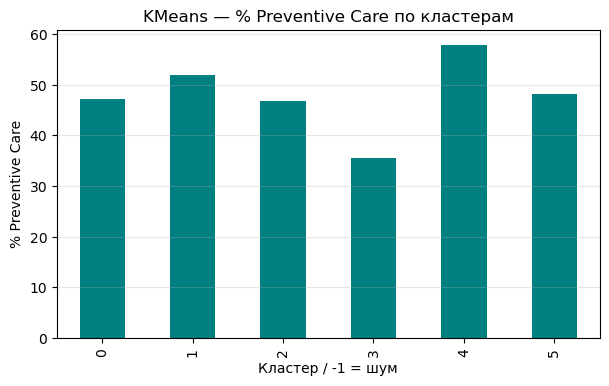

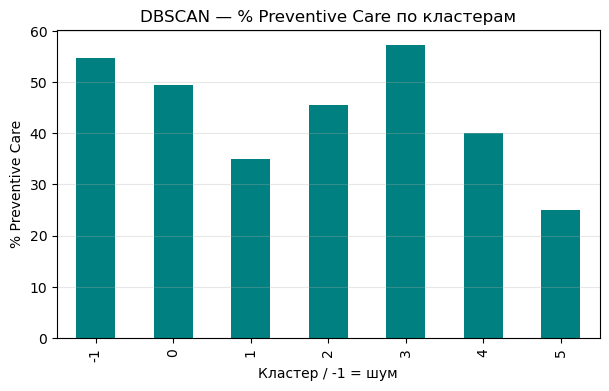

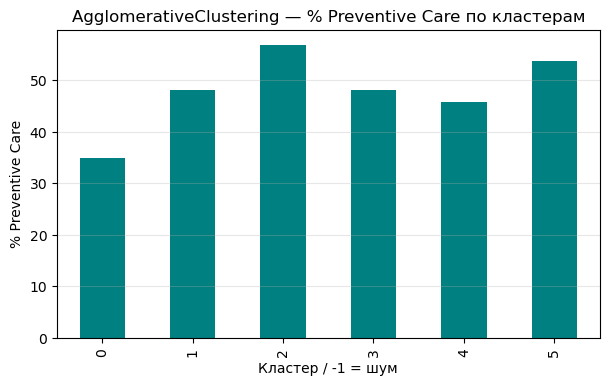

In [44]:
for method, col in [
    ("KMeans",        'cluster_kmeans'),
    ("DBSCAN",        'cluster_dbscan'),
    ("AgglomerativeClustering", 'cluster_agg')
]:
    if col in df.columns:
        prev = df.groupby(col)['Preventive_Care_Flag'].mean() * 100
        plt.figure(figsize=(7,4))
        prev.plot(kind='bar', color='teal')
        plt.title(f"{method} — % Preventive Care по кластерам") # какая доля пациентов в каждом кластере участвует в профилактических мероприятиях
        plt.ylabel("% Preventive Care")
        plt.xlabel("Кластер / -1 = шум")
        plt.grid(axis='y', alpha=0.3)
        plt.show()

### Вывод

По совокупности критериев лучшим методом кластеризации оказался KMeans:

- наивысшие значения метрик качества (silhouette score, Calinski-Harabasz)
- стабильные и воспроизводимые результаты
- чётко разделяющиеся профили кластеров по возрасту, хроническим заболеваниям, количеству визитов, затратам и доле участия в профилактических программах
- отсутствие большого количества точек-выбросов (в отличие от DBSCAN)

DBSCAN показал визуально более контрастные графики в некоторых проекциях, но значительно уступил по метрикам качества и дал заметную долю точек шума, что менее удобно для бизнес-сегментации.

### Сохраним лучший метод

In [12]:
joblib.dump(kmeans, 'best_model.kpl')

['best_model.kpl']

In [13]:
df.to_csv('patient_segmentation_dataset_with_clusters.csv', index=False)